In [1]:
from sklearn import metrics 
import numpy as np
from matplotlib import pyplot as plt
from my_ml_package.visualize import plot_cm

## When could Accuracy be a bad metric?

In [15]:
# 1 represents the cancer people; 0 represents the non-cancer people
y =                       [0, 0, 0, 0, 1, 1, 1, 1] 

# 2 non-cancer (0) -> cancer (1), defined as FP (False Positive)
y_2non_cancer_to_cancer = [1, 1, 0, 0, 1, 1, 1, 1]  # 6/8
#                          *  * 
# 1 cancer (1) ->  non-cancer (0), defined as FN (False Negative)
y_1cancer_to_non_cancer = [0, 0, 0, 0, 1, 0, 1, 1]   # 7/8 
#                                         *
print('=====Accuracy=====')
print('2 non-cancer (0) -> cancer (1): 6/8=', metrics.accuracy_score(y, y_2non_cancer_to_cancer))
print('1 cancer (1) ->  non-cancer (0): 7/8=', metrics.accuracy_score(y, y_1cancer_to_non_cancer))
print('Better Performance: 1 cancer (1) ->  non-cancer (0)')
print('\n')

print('=====Recall=====')
print('2 non-cancer (0) -> cancer (1): 4/4=', metrics.recall_score(y, y_2non_cancer_to_cancer))
print('1 cancer (1) ->  non-cancer (0): 3/4=', metrics.recall_score(y, y_1cancer_to_non_cancer))
print('Better Performance: 2 non-cancer (0) -> cancer (1)')

=====Accuracy=====
2 non-cancer (0) -> cancer (1): 6/8= 0.75
1 cancer (1) ->  non-cancer (0): 7/8= 0.875
Better Performance: 1 cancer (1) ->  non-cancer (0)


=====Recall=====
2 non-cancer (0) -> cancer (1): 4/4= 1.0
1 cancer (1) ->  non-cancer (0): 3/4= 0.75
Better Performance: 2 non-cancer (0) -> cancer (1)


* What if the disease it detects is “CoVid” while there is a lack of doctors for diagnosis? 
  * So we are more likely to favour FP rather than FN.

In [3]:
# 1 represents the covid people; 0 represents the non-covid people
y =                       [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]

# 2 non-covid (0) -> covid (1)
y_3non_covid_mispredict = [1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1] # 2 non-covid -> covid
#                          *  *
# 3 covid (0) -> no covid (1)
y_2covid_mispredict =     [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1]  
#                                      *  *  *

print('=====Accuracy=====')
print('2 non-covid (0) -> covid (1): 10/12=', metrics.accuracy_score(y, y_3non_covid_mispredict))
print('3 covid (1) ->  non-covid (0): 9/12=', metrics.accuracy_score(y, y_2covid_mispredict))
print('Better Performance: 2 non-covid (0) -> covid (1)')
print('\n')
print('=====Recall=====')
print('2 non-covid (0) -> covid (1): 8/8=', metrics.recall_score(y, y_3non_covid_mispredict))
print('3 covid (1) ->  non-covid (0): 5/8=', metrics.recall_score(y, y_2covid_mispredict))
print('Better Performance: 2 non-covid (0) -> covid (1)')
print('\n')
print('=====Precision=====')
print('2 non-covid (0) -> covid (1): 8/10=', metrics.precision_score(y, y_3non_covid_mispredict))
print('1 covid (1) ->  non-covid (0): 5/5=', metrics.precision_score(y, y_2covid_mispredict))
print('Better Performance: 3 covid (1) ->  non-covid (0)')



=====Accuracy=====
2 non-covid (0) -> covid (1): 10/12= 0.8333333333333334
3 covid (1) ->  non-covid (0): 9/12= 0.75
Better Performance: 2 non-covid (0) -> covid (1)


=====Recall=====
2 non-covid (0) -> covid (1): 8/8= 1.0
3 covid (1) ->  non-covid (0): 5/8= 0.625
Better Performance: 2 non-covid (0) -> covid (1)


=====Precision=====
2 non-covid (0) -> covid (1): 8/10= 0.8
1 covid (1) ->  non-covid (0): 5/5= 1.0
Better Performance: 3 covid (1) ->  non-covid (0)


## Formalizing Precision and Recall using Confusion Matrix

* The two metrics are called [Recall and Precision](https://en.wikipedia.org/wiki/Precision_and_recall)
    + We want to correctly detect actually Covid patients, i.e., aiming to decrease FN
    + Recall $\frac{TP}{TP+FN}$  (Sensitivity or TPR): hit rate.
   
    + but also want to reflect FP: false alarm (incorrectly detecting healthy patients as having Covid)
    + Precision $\frac{TP}{TP+FP}$
    <!-- + Other metrics reflecting FP: ?? -->
    <!-- Specificity=$\frac{TN}{N}=\frac{TN}{TN+FP}$ -->
    + Opposite directions: the larger the metrics, the more FN/FP
    <!-- missing rate: $\frac{FN}{TP+FP}$ -->
    <!-- FPR=$\frac{FP}{N}=\frac{FP}{TN+FP}$

<!-- precision: how many examples are correctly predicted during all predictions for a target
recall: how many examples are correctly predicted during all examples of one class -->

In [7]:
#               pred0     pred1
# actual 0       [[TN,      ],
# actual 1        [,        ]]

# formulate Accuracy by Confusion Matrix?
y_pred1 = y_3non_covid_mispredict
confusion_matrix = metrics.confusion_matrix(y, y_pred1)
print(confusion_matrix)
# plot_cm(y, y_pred1, labels=['0', '1'])

[[2 2]
 [0 8]]


In [ ]:
# print('Recall for FP predictions: ', metrics.recall_score(y, y_pred1))
# print('Precision for FP predictions: ', metrics.precision_score(y, y_pred1))

# print('Recall for FN predictions: ', metrics.recall_score(y, y_pred2))
# print('Precision for FN predictions: ', metrics.precision_score(y, y_pred2))


* F1: Balancing Recall and Precision


In [9]:
# F1 = 2 * (precision * recall) / (precision + recall)
# print(metrics.classification_report(y, y_pred1, labels=[0, 1], target_names=["zero","one"]))

* How we can reduce misclassification for one class of examples? 
    + we always have a tradeoff between FN and FP. since, in reality, the model will output probabilities rather than directly give the class.
*  How would reducing misclassification for one class of examples likely increase misclassification for another class of examples?



In [16]:
# I take the demonstrated example from https://www.youtube.com/watch?v=4jRBRDbJemM&t=655s
y =      np.array([0,   0,   0,   0,   1,   1,   1,   1])
y_prob = np.array([0.5, 0.2, 0,   0,   0.5, 1,   1,   1])
y_pred = y_prob >= 0.5
print(y_pred)
print("FN", metrics.confusion_matrix(y, y_pred)[1,0])
print("FP", metrics.confusion_matrix(y, y_pred)[0,1])


[ True False False False  True  True  True  True]
FN 0
FP 1


* ROC (Receiver Operating Characteristic) Curve reflecting the trade-off between FN and FP 
    + True Positive Rate (TPR, i.e., recall): 1 when FN is 0
    + False Positive Rate (FPR): 0 when FP is 0; Which metric can be used to replace FPR?
    + So the best point is (FPR, TPR) = (0, 1)
    + (0, 0) is the extreme model for reducing FP
    + (1, 1) is the extreme model for reducing FN
    

[inf 1.  0.5 0.2 0. ]


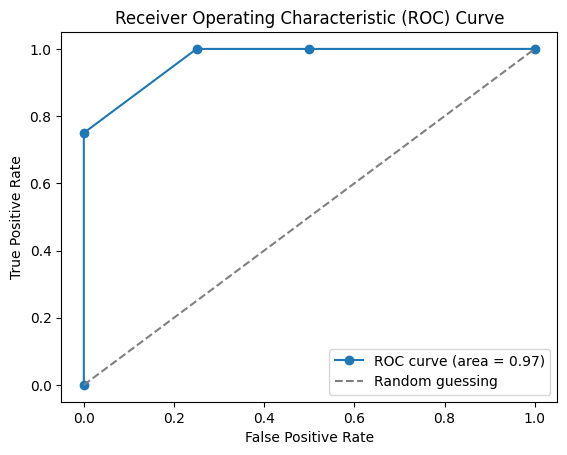

In [17]:
fpr, tpr, thresholds = metrics.roc_curve(y, y_prob)
print(thresholds)
# Calculate AUC
auc = metrics.auc(fpr, tpr)
# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, marker='o', label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guessing')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

But they have different significaces in the real world.
* In which cases we do not want people with disease midclassified as no disease, i.e., less FN?
    + life threathening scenarios, e.g., heart disease, cancer
    + disease easily causing outbreak, e.g., Covid
    
    
* In which cases we do not want healthy people misclassified as with disease, i.e., less FP
    + small problems causing unnecessary hospital cost, e.g., diarrhea